## [1]

In [26]:
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

centers = [
    [+1,+1,+1,+1,+1,+1,+1,+1],  # Класс 0
    [-1,-1,-1,-1,-1,-1,-1,-1],  # Класс 1
    [+1,-1,+1,-1,+1,-1,+1,-1]   # Класс 2
]

X, y = make_blobs(n_samples=300, n_features=8, centers=centers, cluster_std=0.5, random_state=42)
df = pd.DataFrame(X, columns=[f'f{i}' for i in range(8)])
df['class'] = y

df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,class
0,-0.163714,-0.790490,-1.352506,-1.027885,-0.720837,-0.961997,-0.730622,-1.460337,1
1,-1.010684,-1.373606,-2.212120,-0.557977,-0.631578,-1.140664,-0.966505,-0.742030,1
2,1.084230,-0.341201,0.496729,-0.430061,1.658558,-1.059034,-0.060927,-1.303911,2
3,0.499834,-1.338872,1.256954,-0.910209,1.175315,-0.755406,1.317361,-0.445150,2
4,1.583891,1.127210,1.168801,0.794062,0.756197,0.783721,1.197226,0.789508,0


In [27]:
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,class
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.329425,-0.260198,0.338257,-0.292758,0.344267,-0.333724,0.342263,-0.341464,1.000000
std,1.029373,1.069687,1.072776,1.066816,0.994325,1.013084,1.024894,1.070762,0.817861
min,-2.249703,-2.211940,-2.276961,-2.470194,-1.996868,-2.448128,-1.918103,-2.460675,0.000000
25%,-0.624735,-1.096133,-0.683879,-1.131916,-0.620614,-1.118889,-0.623895,-1.173609,0.000000
50%,0.697680,-0.574371,0.672787,-0.647456,0.641563,-0.672604,0.648983,-0.701124,1.000000
75%,1.128476,0.745360,1.219906,0.627437,1.100755,0.571555,1.136008,0.632704,2.000000
max,2.206308,2.926366,2.280042,2.360085,2.157329,2.095228,2.539440,2.135346,2.000000


In [28]:
# %% Корреляции
df.corr()

,f0,f1,f2,f3,f4,f5,f6,f7,class
f0,1.000000,0.437587,0.784863,0.359149,0.781224,0.341119,0.762047,0.388861,0.008593
f1,0.437587,1.000000,0.463427,0.786950,0.463105,0.753410,0.424415,0.808926,-0.738693
f2,0.784863,0.463427,1.000000,0.399650,0.795439,0.369267,0.760806,0.435221,-0.039871
f3,0.359149,0.786950,0.399650,1.000000,0.343049,0.770478,0.356539,0.774724,-0.779582
f4,0.781224,0.463105,0.795439,0.343049,1.000000,0.336313,0.746120,0.416638,-0.002993
f5,0.341119,0.753410,0.369267,0.770478,0.336313,1.000000,0.324513,0.767422,-0.777338
f6,0.762047,0.424415,0.760806,0.356539,0.746120,0.324513,1.000000,0.401071,0.017269
f7,0.388861,0.808926,0.435221,0.774724,0.416638,0.767422,0.401071,1.000000,-0.752243
class,0.008593,-0.738693,-0.039871,-0.779582,-0.002993,-0.777338,0.017269,-0.752243,1.000000


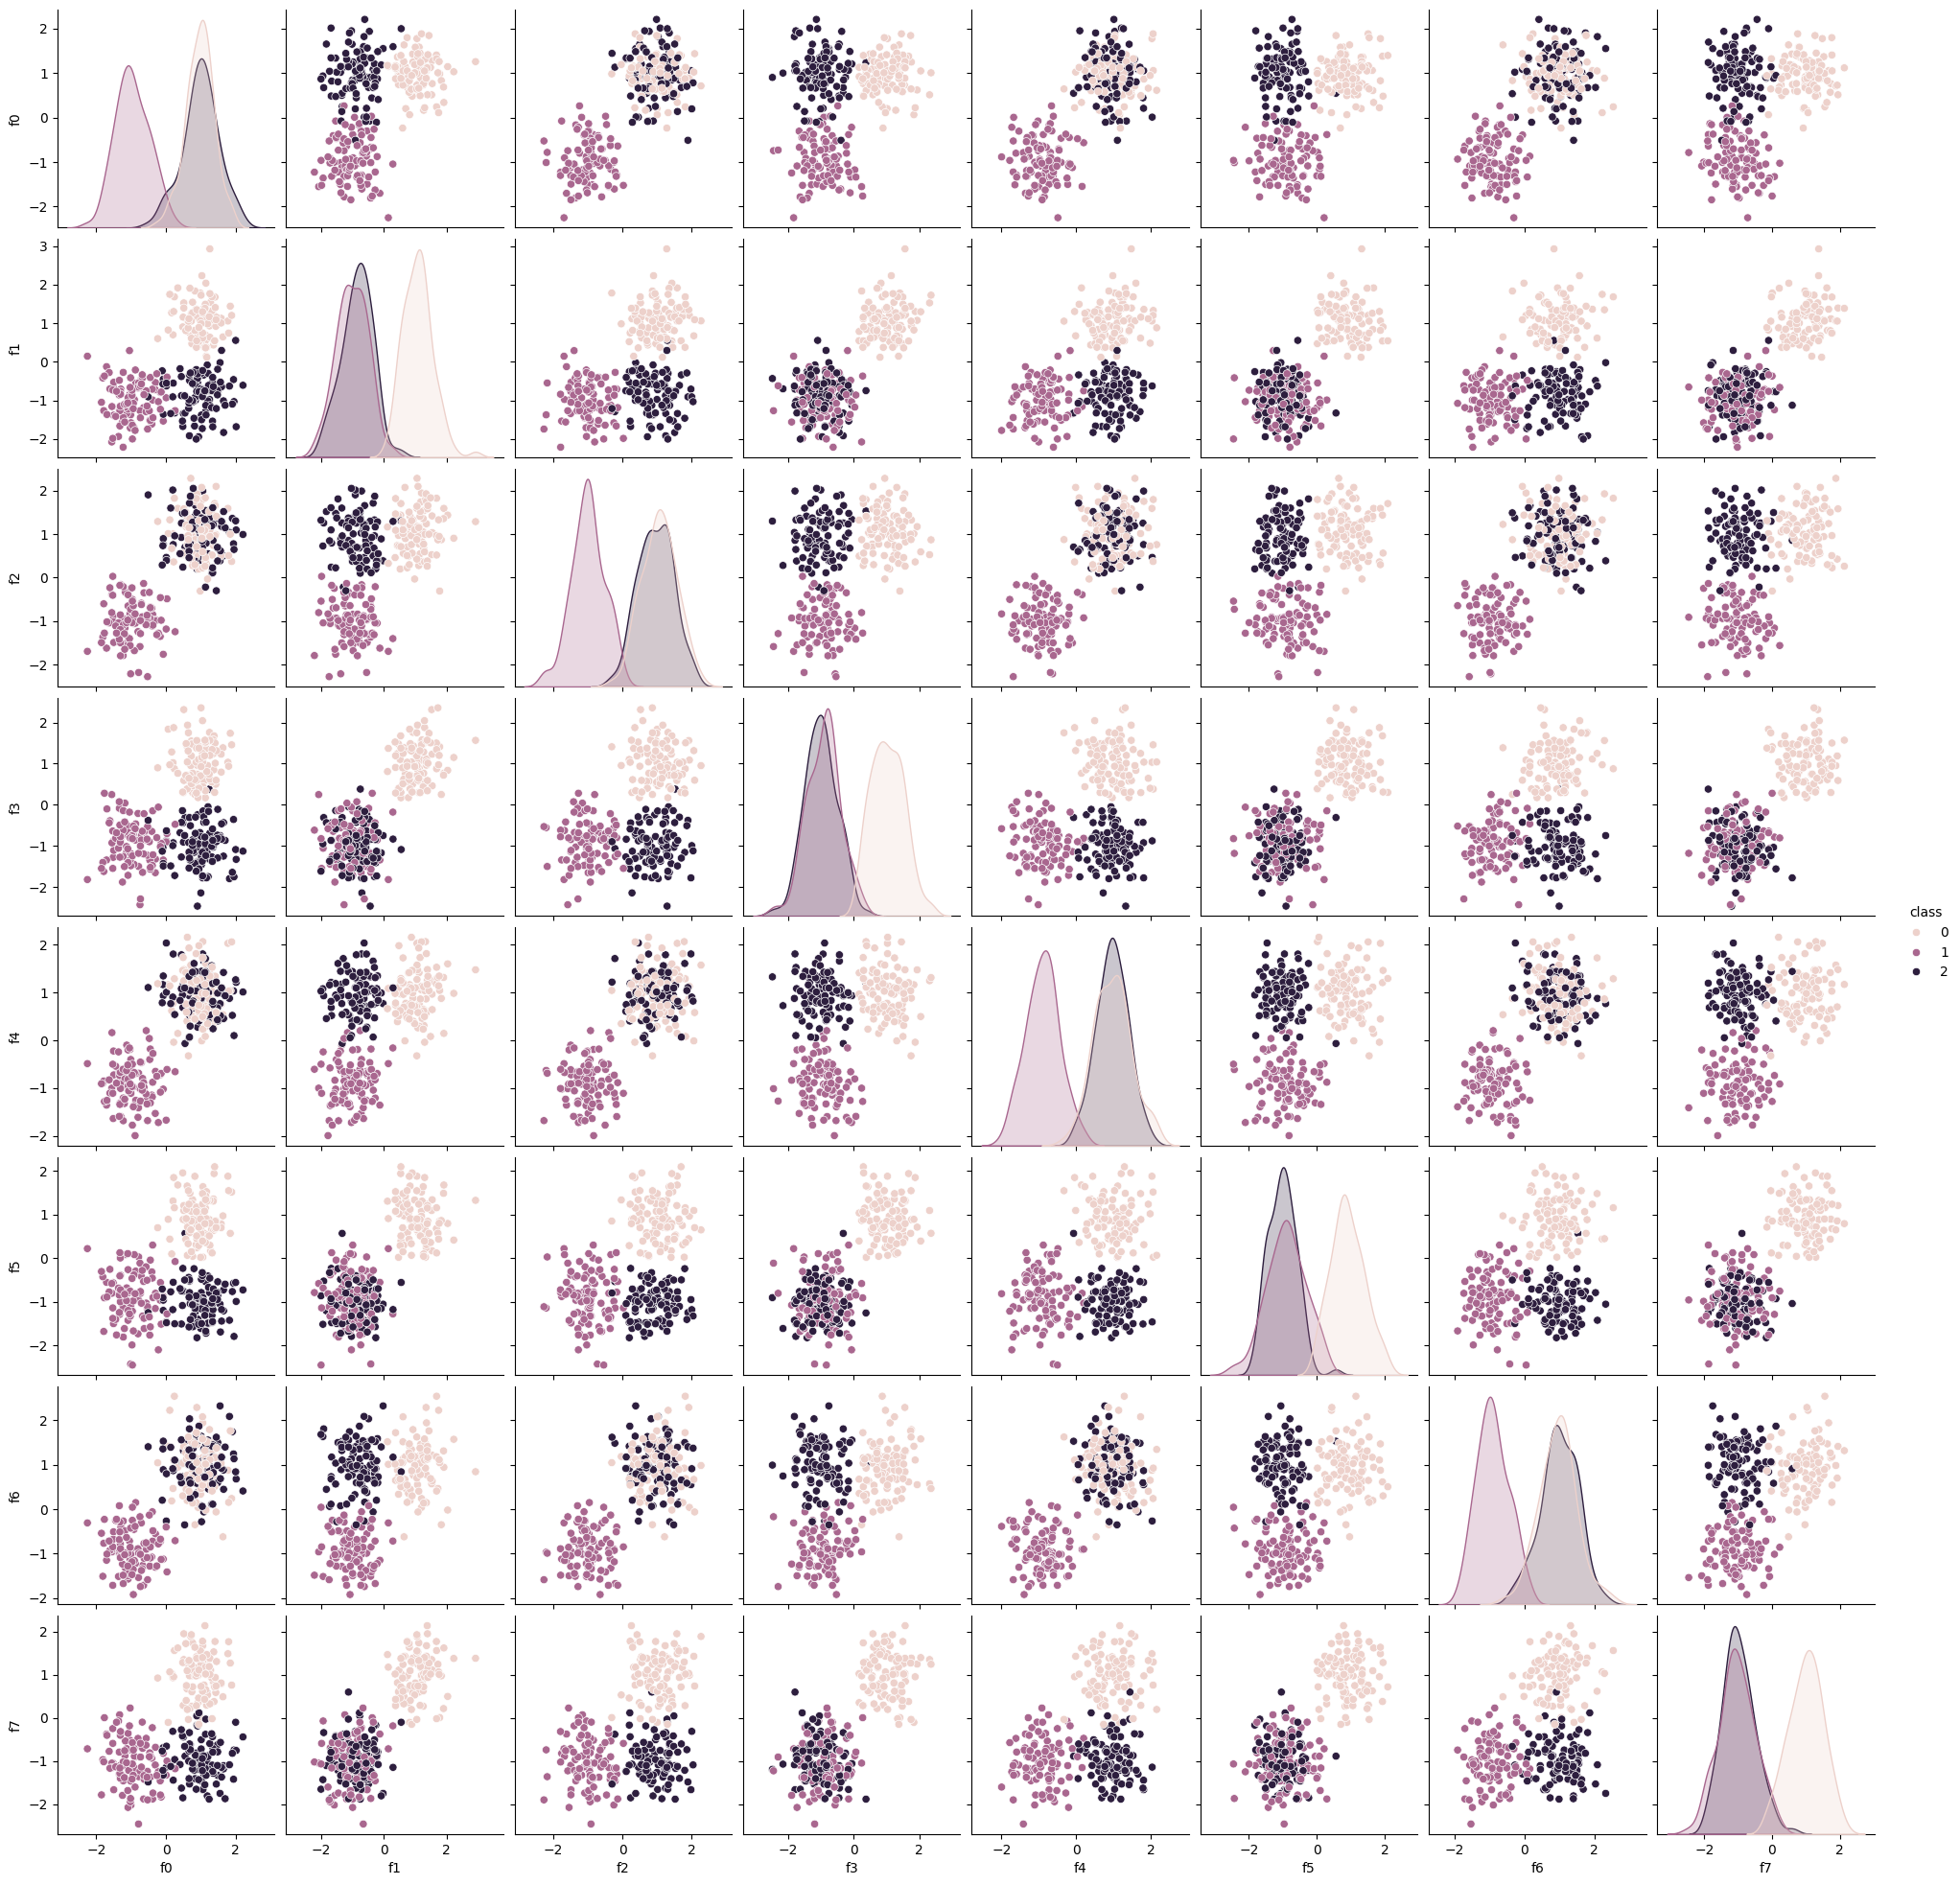

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='class', diag_kind='kde')
plt.show()

## [2]

In [30]:
import pandas as pd
import numpy as np

df0 = df[df['class'] == 0].copy()

results = {}
for A in [1, 10, 100]:
    for B in [1, 10, 100]:
        name = f'df_{A}_{B}'
        new_points = pd.DataFrame(
            np.tile([-B, +B, -B, +B, -B, +B, -B, +B], (A, 1)),
            columns=[f'f{i}' for i in range(8)]
        )
        new_points['class'] = 0
        
        df_ab = pd.concat([
            df0.iloc[:100],  # оригинальные 100 точек класса 0
            new_points,
            df[df['class'] == 1],
            df[df['class'] == 2]
        ], ignore_index=True)
        
        results[name] = df_ab
        print(f"{name}: {len(df_ab)} объектов")

df_1_1: 301 объектов
df_1_10: 301 объектов
df_1_100: 301 объектов
df_10_1: 310 объектов
df_10_10: 310 объектов
df_10_100: 310 объектов
df_100_1: 400 объектов
df_100_10: 400 объектов
df_100_100: 400 объектов


## [3]

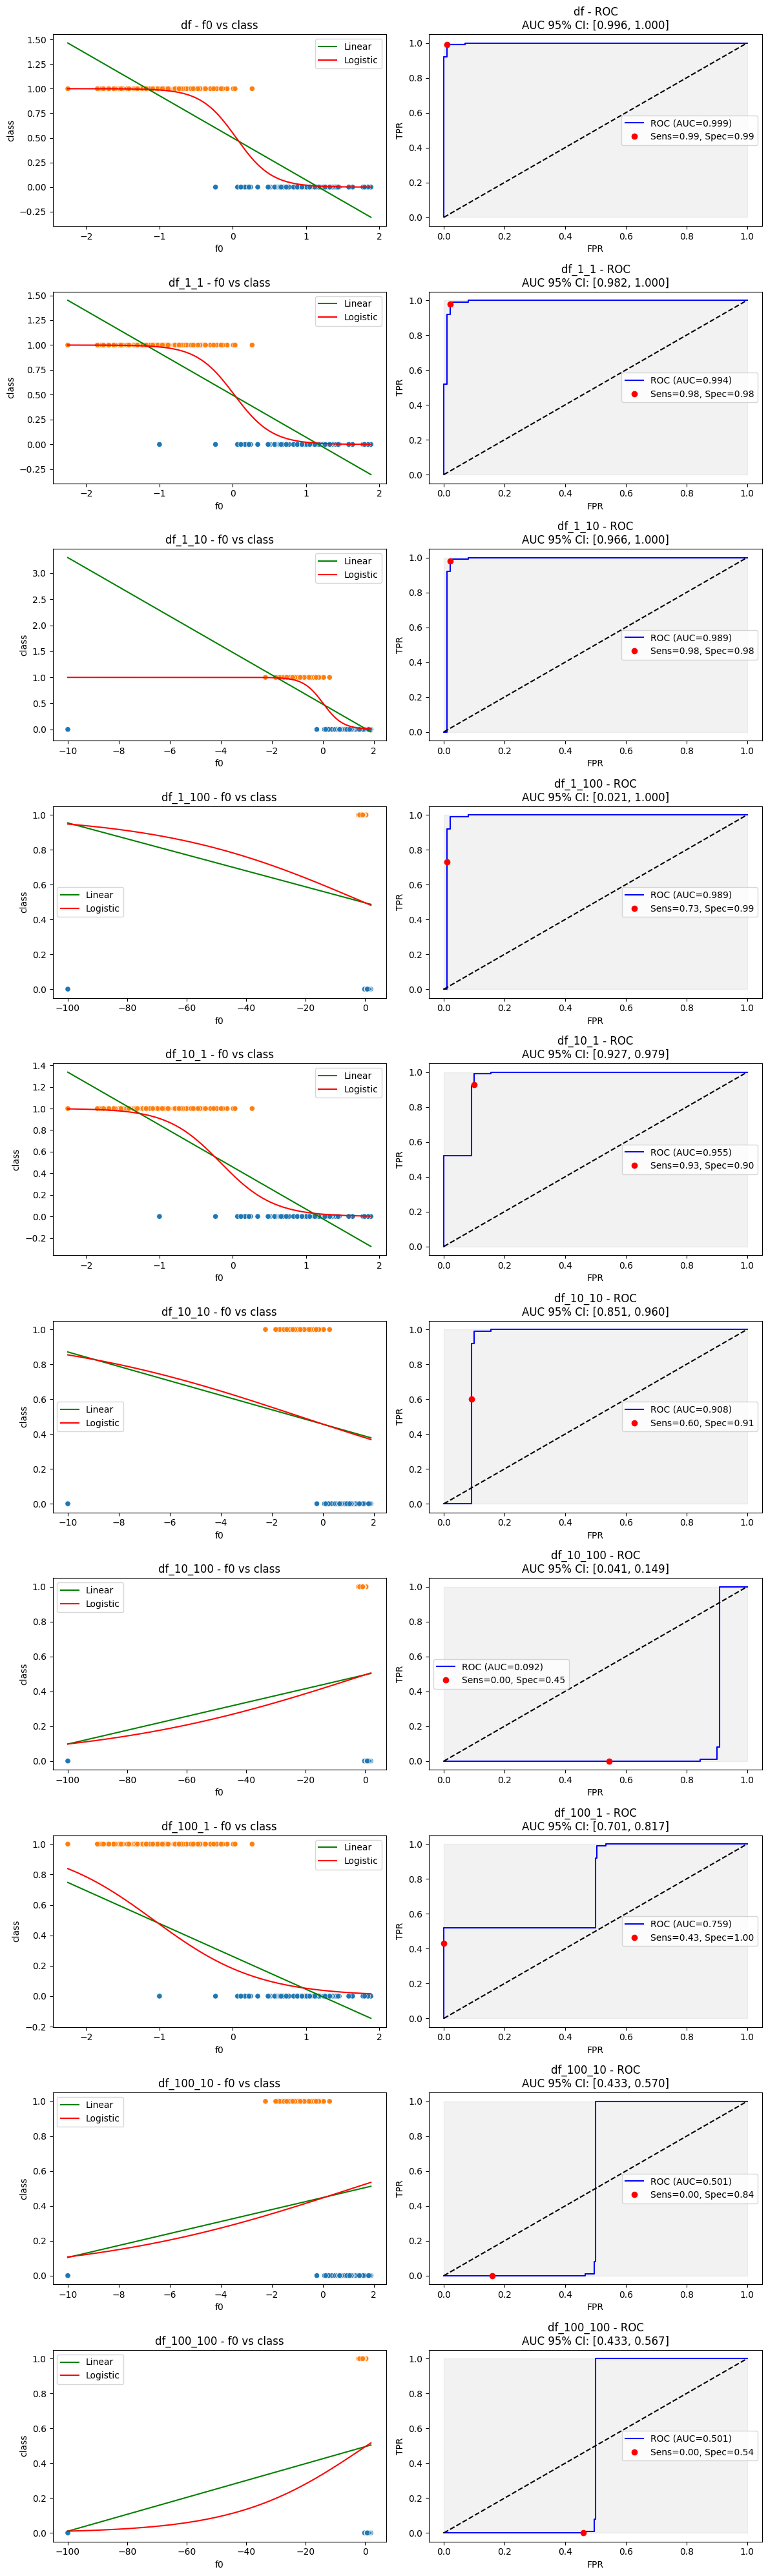

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import seaborn as sns

datasets = {'df': df} | results  # df + все df_A_B
feature = 'f0'
classes = [0, 1]

fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4*len(datasets)))
if len(datasets) == 1: axes = axes.reshape(1, -1)

for idx, (name, data) in enumerate(datasets.items()):
    sub = data[data['class'].isin(classes)].copy()
    X = sub[[feature]].values
    y = (sub['class'] == 1).astype(int).values  # 1 vs 0
    
    lin_reg = LinearRegression().fit(X, y)
    log_reg = LogisticRegression().fit(X, y)
    
    x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_lin = lin_reg.predict(x_plot)
    y_log = log_reg.predict_proba(x_plot)[:, 1]
    
    # Левая колонка: пространство + регрессии
    ax1 = axes[idx, 0]
    sns.scatterplot(data=sub, x=feature, y='class', hue='class', ax=ax1, legend=False)
    ax1.plot(x_plot, y_lin, color='green', label='Linear')
    ax1.plot(x_plot, y_log, color='red', label='Logistic')
    ax1.set_title(f"{name} - {feature} vs class")
    ax1.legend()
    
    # ROC и бутстреп CI
    fpr, tpr, thr = roc_curve(y, log_reg.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Точка классификации (по умолчанию threshold=0.5)
    prob = log_reg.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    sens = np.mean(pred[y==1] == 1) if (y==1).sum() > 0 else 0
    spec = np.mean(pred[y==0] == 0) if (y==0).sum() > 0 else 0
    
    # Бутстреп CI95 для AUC
    aucs = []
    for _ in range(1000):
        Xb, yb = resample(X, y)
        if len(np.unique(yb)) < 2: continue
        try:
            logb = LogisticRegression().fit(Xb, yb)
            fb, tb, _ = roc_curve(yb, logb.predict_proba(Xb)[:, 1])
            aucs.append(auc(fb, tb))
        except: pass
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5])
    
    # Правая колонка: ROC
    ax2 = axes[idx, 1]
    ax2.plot(fpr, tpr, color='blue', label=f'ROC (AUC={roc_auc:.3f})')
    ax2.plot([0,1], [0,1], 'k--')
    ax2.plot(1-spec, sens, 'ro', label=f'Sens={sens:.2f}, Spec={spec:.2f}')
    ax2.fill_between([0,1], 0, 1, color='gray', alpha=0.1)
    ax2.set_title(f"{name} - ROC\nAUC 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
    ax2.legend()
    ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')

plt.tight_layout()
plt.show()

## [4]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

features = ['f0', 'f1', 'f2', 'f3']
classes = [0, 1]
datasets = {'df': df} | results

log_datasets = {}

for name, data in datasets.items():
    sub = data[data['class'].isin(classes)].copy()
    X = sub[features].values
    y = (sub['class'] == 1).astype(int).values  # 1 для класса 1, 0 для класса 0
    
    # Множественная линейная регрессия
    lin_reg = LinearRegression().fit(X, y)
    coef = lin_reg.coef_
    intercept = lin_reg.intercept_
    
    # Уравнение: Y = intercept + coef[0]*f0 + coef[1]*f1 + coef[2]*f2 + coef[3]*f3
    print(f"{name}: Y = {intercept:.4f} + {coef[0]:.4f}*f0 + {coef[1]:.4f}*f1 + {coef[2]:.4f}*f2 + {coef[3]:.4f}*f3")
    
    # Новый признак X_lin = линейная комбинация
    X_lin = X @ coef + intercept
    logdf = pd.DataFrame({
        'X': X_lin,
        'Y': y
    })
    log_datasets[f'log{name}'] = logdf

logdf.head()

df: Y = 0.5137 + -0.1340*f0 + -0.1166*f1 + -0.1182*f2 + -0.1023*f3
df_1_1: Y = 0.5118 + -0.1229*f0 + -0.1272*f1 + -0.1090*f2 + -0.1114*f3
df_1_10: Y = 0.5145 + -0.1128*f0 + -0.1363*f1 + -0.1012*f2 + -0.1198*f3
df_1_100: Y = 0.5143 + -0.1232*f0 + -0.1266*f1 + -0.1095*f2 + -0.1112*f3
df_10_1: Y = 0.5026 + -0.0682*f0 + -0.1793*f1 + -0.0637*f2 + -0.1564*f3
df_10_10: Y = 0.5145 + -0.1105*f0 + -0.1385*f1 + -0.0993*f2 + -0.1217*f3
df_10_100: Y = 0.5143 + -0.1232*f0 + -0.1266*f1 + -0.1095*f2 + -0.1112*f3
df_100_1: Y = 0.4919 + -0.0045*f0 + -0.2398*f1 + -0.0109*f2 + -0.2088*f3
df_100_10: Y = 0.5146 + -0.1102*f0 + -0.1387*f1 + -0.0991*f2 + -0.1219*f3
df_100_100: Y = 0.5143 + -0.1232*f0 + -0.1266*f1 + -0.1095*f2 + -0.1112*f3


,X,Y
0,-0.039897,0
1,-0.057286,0
2,-0.007285,0
3,-0.084936,0
4,-0.047763,0


## [5]

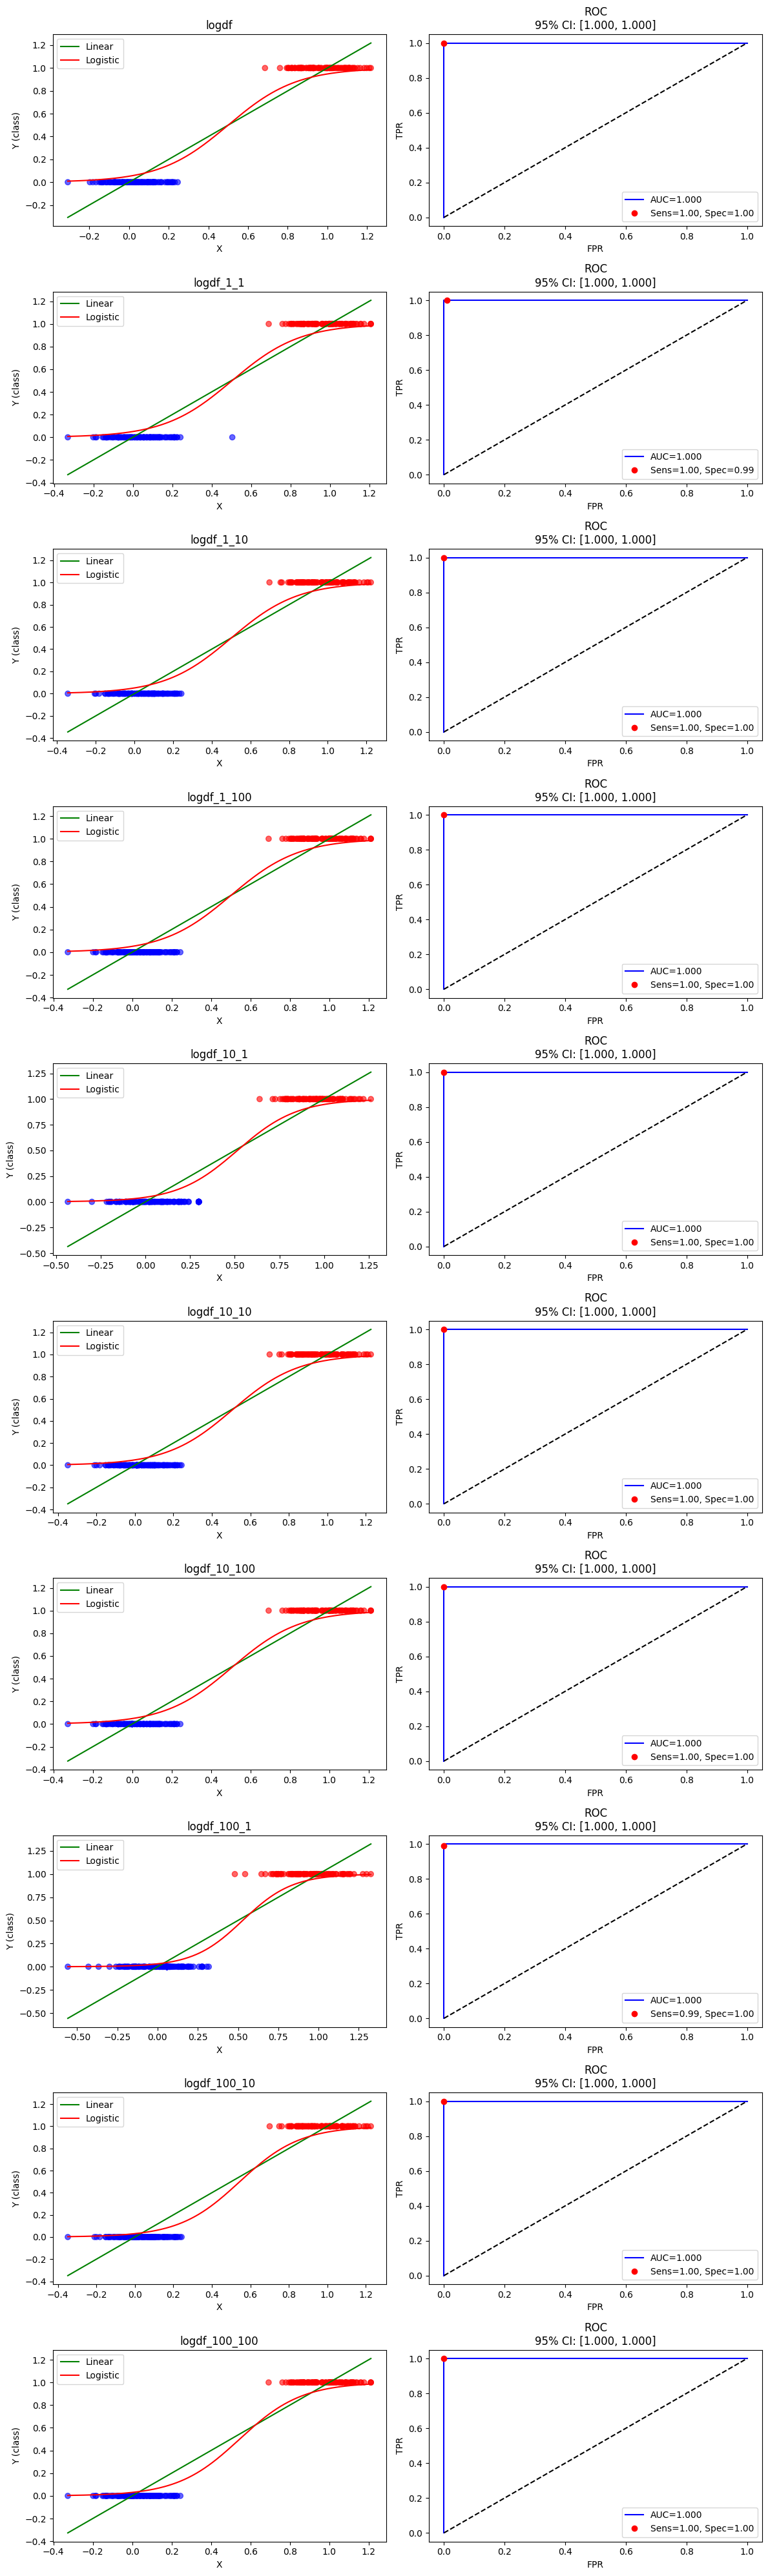

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

fig, axes = plt.subplots(len(log_datasets), 2, figsize=(12, 4*len(log_datasets)))
if len(log_datasets) == 1: axes = axes.reshape(1, -1)

for idx, (name, data) in enumerate(log_datasets.items()):
    X = data[['X']].values
    y = data['Y'].values
    
    lin_reg = LinearRegression().fit(X, y)
    log_reg = LogisticRegression().fit(X, y)
    
    x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_lin = lin_reg.predict(x_plot)
    y_log = log_reg.predict_proba(x_plot)[:, 1]
    
    # Левая: пространство + регрессии
    ax1 = axes[idx, 0]
    ax1.scatter(X, y, c=y, cmap='bwr', alpha=0.6)
    ax1.plot(x_plot, y_lin, 'g-', label='Linear')
    ax1.plot(x_plot, y_log, 'r-', label='Logistic')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y (class)')
    ax1.set_title(f"{name}")
    ax1.legend()
    
    # ROC + CI
    prob = log_reg.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, prob)
    roc_auc = auc(fpr, tpr)
    
    pred = (prob >= 0.5).astype(int)
    sens = np.mean(pred[y==1] == 1) if (y==1).sum() > 0 else 0
    spec = np.mean(pred[y==0] == 0) if (y==0).sum() > 0 else 0
    
    # Бутстреп CI95 AUC
    aucs = []
    for _ in range(1000):
        Xb, yb = resample(X, y)
        if len(np.unique(yb)) < 2: continue
        try:
            lb = LogisticRegression().fit(Xb, yb)
            fb, tb, _ = roc_curve(yb, lb.predict_proba(Xb)[:, 1])
            aucs.append(auc(fb, tb))
        except: pass
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5]) if aucs else (0, 0)
    
    # Правая: ROC
    ax2 = axes[idx, 1]
    ax2.plot(fpr, tpr, 'b', label=f'AUC={roc_auc:.3f}')
    ax2.plot([0,1],[0,1],'k--')
    ax2.plot(1-spec, sens, 'ro', label=f'Sens={sens:.2f}, Spec={spec:.2f}')
    ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
    ax2.set_title(f"ROC\n95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
    ax2.legend()

plt.tight_layout()
plt.show()

## [6]

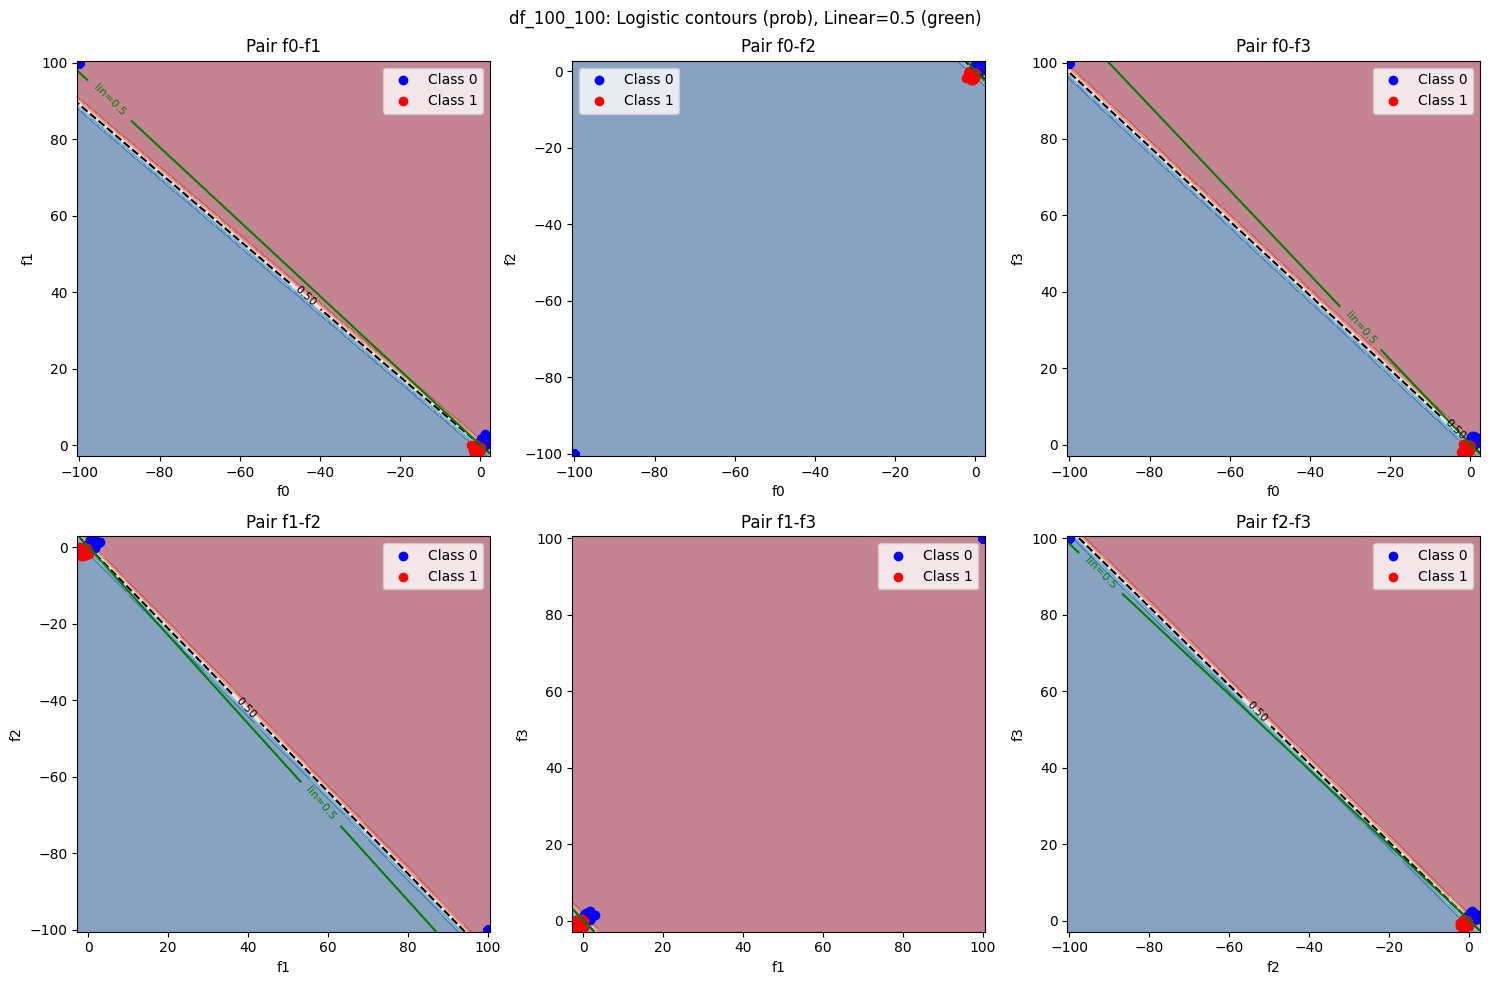

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from itertools import combinations

df_ab = results['df_100_100']  # пример: сильный дисбаланс
sub = df_ab[df_ab['class'].isin([0, 1])].copy()
X = sub[['f0','f1','f2','f3']].values
y = (sub['class'] == 1).astype(int).values

lin_reg = LinearRegression().fit(X, y)
log_reg = LogisticRegression().fit(X, y)

pairs = list(combinations(range(4), 2))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (i, j) in enumerate(pairs):
    ax = axes[idx//3, idx%3]
    x1, x2 = i, j
    x_grid = np.linspace(X[:,x1].min()-0.5, X[:,x1].max()+0.5, 100)
    y_grid = np.linspace(X[:,x2].min()-0.5, X[:,x2].max()+0.5, 100)
    XX, YY = np.meshgrid(x_grid, y_grid)
    
    grid = np.zeros((XX.size, 4))
    grid[:, x1] = XX.ravel()
    grid[:, x2] = YY.ravel()
    
    Z_lin = lin_reg.predict(grid).reshape(XX.shape)
    Z_log = log_reg.predict_proba(grid)[:, 1].reshape(XX.shape)
    
    ax.contourf(XX, YY, Z_log, levels=10, alpha=0.5, cmap='RdBu')
    cs = ax.contour(XX, YY, Z_log, levels=[0.5], colors='black', linestyles='--')
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')
    
    ax.scatter(X[y==0, x1], X[y==0, x2], c='blue', label='Class 0')
    ax.scatter(X[y==1, x1], X[y==1, x2], c='red', label='Class 1')
    
    lin_pred = Z_lin
    cs_lin = ax.contour(XX, YY, lin_pred, levels=[0.5], colors='green')
    ax.clabel(cs_lin, inline=True, fontsize=8, fmt='lin=0.5')
    
    ax.set_xlabel(f'f{x1}'); ax.set_ylabel(f'f{x2}')
    ax.set_title(f'Pair f{x1}-f{x2}')
    ax.legend()

plt.suptitle('df_100_100: Logistic contours (prob), Linear=0.5 (green)')
plt.tight_layout()
plt.show()